With Lag Features

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [5]:
# Load dataset
df = pd.read_csv(r"E:\OneDrive\Bsc.Eng - Final\SEM 07 - OD\FYP\FYP 2\Step 4 - Final\LSTM Model\boralesgamuwa_weather_2025_01_01_to_2025_12_31_15min_interpolated_power_added_final_set.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
0,2025-01-01 00:00:00,24.2,92.0,100.0,0.0,8.100,0.0
1,2025-01-01 00:15:00,24.1,92.5,100.0,0.0,8.275,0.0
2,2025-01-01 00:30:00,24.0,93.0,100.0,0.0,8.450,0.0
3,2025-01-01 00:45:00,23.9,93.5,100.0,0.0,8.625,0.0
4,2025-01-01 01:00:00,23.8,94.0,100.0,0.0,8.800,0.0


In [6]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
35035,2025-12-31 22:45:00,24.15,94.0,100.0,0.0,6.2,0.0
35036,2025-12-31 23:00:00,24.30,94.0,100.0,0.0,6.0,0.0
35037,2025-12-31 23:15:00,24.45,94.0,100.0,0.0,5.8,0.0
35038,2025-12-31 23:30:00,24.60,94.0,100.0,0.0,5.6,0.0
35039,2025-12-31 23:45:00,24.75,94.0,100.0,0.0,5.4,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       34956 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB


In [8]:
#  Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       35040 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB
None


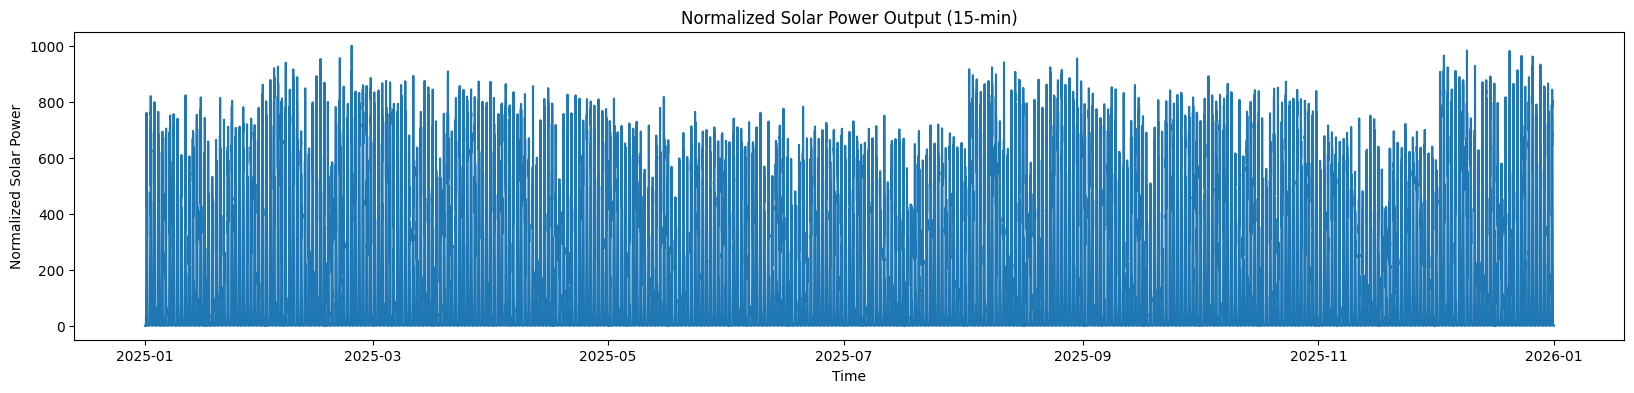

In [9]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["solar_normalize"])
plt.title("Normalized Solar Power Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Solar Power")
plt.show()

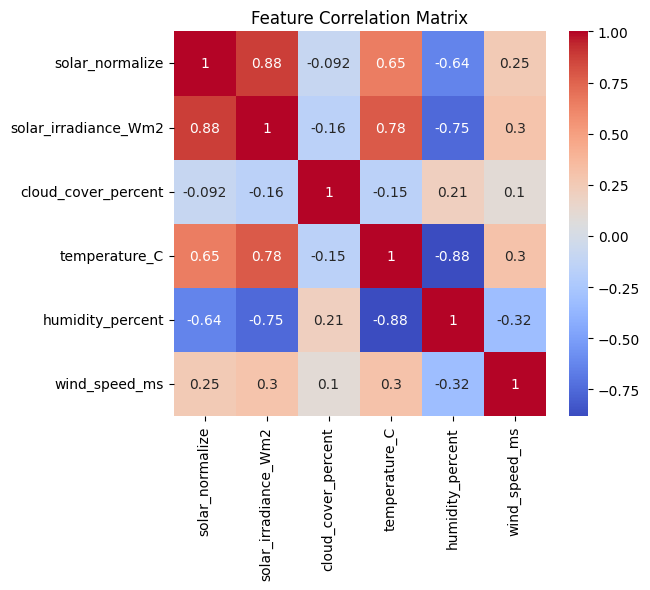

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "solar_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
# Time-based features
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofyear"] = df["timestamp"].dt.dayofyear

# Solar power lags
df["solar_lag_1"] = df["solar_normalize"].shift(1)
df["solar_lag_2"] = df["solar_normalize"].shift(2)
df["solar_lag_4"] = df["solar_normalize"].shift(4)

#Drop NaN
df = df.dropna()

# Ramp rate (intra-hour variability)
#df["solar_ramp"] = df["solar_normalize"] - df["solar_lag_1"]

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35036 entries, 4 to 35039
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35036 non-null  datetime64[ns]
 1   temperature_C         35036 non-null  float64       
 2   humidity_percent      35036 non-null  float64       
 3   cloud_cover_percent   35036 non-null  float64       
 4   solar_irradiance_Wm2  35036 non-null  float64       
 5   wind_speed_ms         35036 non-null  float64       
 6   solar_normalize       35036 non-null  float64       
 7   hour                  35036 non-null  int32         
 8   minute                35036 non-null  int32         
 9   dayofyear             35036 non-null  int32         
 10  solar_lag_1           35036 non-null  float64       
 11  solar_lag_2           35036 non-null  float64       
 12  solar_lag_4           35036 non-null  float64       
dtypes: datetime64[ns](1),

In [13]:
y = df[["solar_normalize"]]
X = df[
    [
        "solar_irradiance_Wm2",
        "temperature_C",
        "wind_speed_ms",
        "hour",
        "minute",
        "dayofyear",
        "solar_lag_1",
        "solar_lag_2",
        "solar_lag_4"
        # "solar_ramp"
    ]
]

In [14]:
len(X), len(y)

(35036, 35036)

In [15]:
X.head()

,solar_irradiance_Wm2,temperature_C,wind_speed_ms,hour,minute,dayofyear,solar_lag_1,solar_lag_2,solar_lag_4
4,0.0,23.80,8.80,1,0,1,0.0,0.0,0.0
5,0.0,23.75,9.35,1,15,1,0.0,0.0,0.0
6,0.0,23.70,9.90,1,30,1,0.0,0.0,0.0
7,0.0,23.65,10.45,1,45,1,0.0,0.0,0.0
8,0.0,23.60,11.00,2,0,1,0.0,0.0,0.0


In [16]:
y.head()

,solar_normalize
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0


In [17]:
# Total samples
total_samples = len(df)

# Samples per day (15-min data)
samples_per_day = 96

# Total number of days
total_days = total_samples // samples_per_day

print("Total days:", total_days)

# Split ratios
train_days = int(0.7 * total_days)
val_days   = int(0.15 * total_days)
test_days  = total_days - train_days - val_days

print(train_days, val_days, test_days)

# Convert days → indices
train_end = train_days * samples_per_day
val_end   = train_end + (val_days * samples_per_day)

# Split data (IMPORTANT: no shuffling)
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

Total days: 364
254 54 56


In [18]:
from sklearn.model_selection import ParameterSampler
from lightgbm import early_stopping, log_evaluation

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "num_leaves": [20, 31, 50],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# Randomly sample combinations
param_list = list(ParameterSampler(param_dist, n_iter=15, random_state=42))

best_rmse = float("inf")
best_model = None
best_params = None

for i, params in enumerate(param_list):
    print(f"Trial {i+1}/{len(param_list)}")

    model = LGBMRegressor(random_state=42, **params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
        early_stopping(stopping_rounds=20),log_evaluation(0)
        ],
    )

    y_val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print("RMSE:", rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_params = params


print("\nBest Parameters:", best_params)
print("Best Validation RMSE:", best_rmse)

y_test_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test RMSE:", test_rmse)
print("Best Iteration:", best_model.best_iteration_)


Trial 1/15


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1813
[LightGBM] [Info] Number of data points in the train set: 24384, number of used features: 9
[LightGBM] [Info] Start training from score 170.495633
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [19]:
y_test_np = np.array(y_test)
y_pred_np = np.array(y_test_pred)

# MAE
test_mae = mean_absolute_error(y_test_np, y_pred_np)

# R2 Score
test_r2 = r2_score(y_test_np, y_pred_np)

# RMSE
test_rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))

print("\nTest MAE:", test_mae)
print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)



Test MAE: 27.475672329171722
Test R2: 0.9433593007012342
Test RMSE: 58.403561007024614


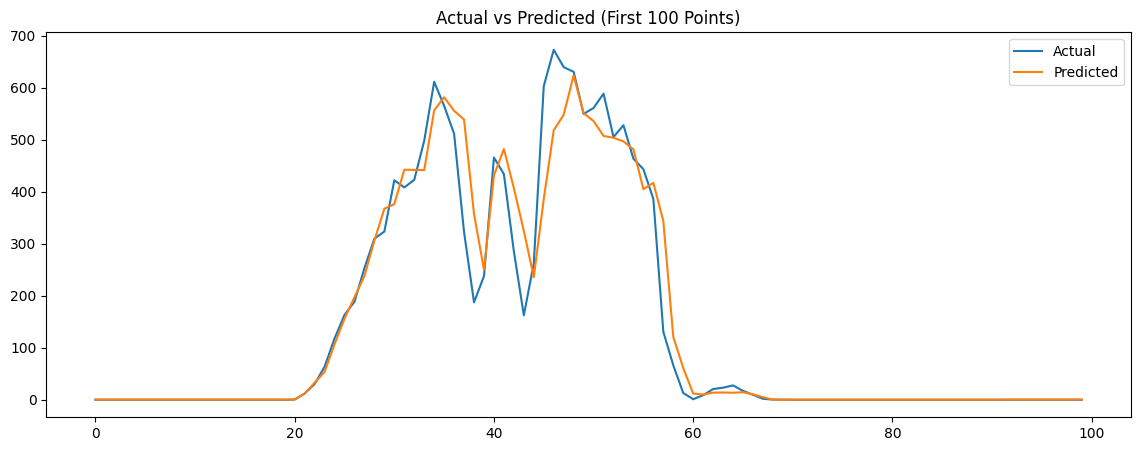

In [20]:
n = 100  # change as needed

plt.figure(figsize=(14,5))

plt.plot(y_test_np[:n], label="Actual")
plt.plot(y_pred_np[:n], label="Predicted")

plt.title(f"Actual vs Predicted (First {n} Points)")
plt.legend()

plt.show()

In [21]:
lag_cols = ["solar_lag_1", "solar_lag_2", "solar_lag_4"]

X_test_base = X_test.drop(columns=lag_cols).copy()
# print(X_test_base.head())

# Ensure y_train is 1D
y_train_values = np.array(y_train).flatten()

# Initialize history buffer (at least 4 values)
history = [0, 0, 0, 0,0]  # safer to take more

predictions = []

for i in range(len(X_test_base)):
    
    row = X_test_base.iloc[i].copy()
    
    # Assign lag values safely
    row["solar_lag_1"] = history[-1]
    row["solar_lag_2"] = history[-2]
    row["solar_lag_4"] = history[-4]
    
    row_df = pd.DataFrame([row])
    
    # Ensure correct column order
    row_df = row_df[X_train.columns]
    print(row_df.head())
    # Predict
    pred = best_model.predict(row_df)[0]
    # Force zero at night
    if row["solar_irradiance_Wm2"] == 0:
         pred = 0
    predictions.append(pred)
    
    # Update history
    history.append(pred)

       solar_irradiance_Wm2  temperature_C  wind_speed_ms  hour  minute  \
29572                   0.0           27.5           11.2   1.0     0.0   

       dayofyear  solar_lag_1  solar_lag_2  solar_lag_4  
29572      309.0          0.0          0.0          0.0  
       solar_irradiance_Wm2  temperature_C  wind_speed_ms  hour  minute  \
29573                   0.0          27.45         11.325   1.0    15.0   

       dayofyear  solar_lag_1  solar_lag_2  solar_lag_4  
29573      309.0          0.0          0.0          0.0  
       solar_irradiance_Wm2  temperature_C  wind_speed_ms  hour  minute  \
29574                   0.0           27.4          11.45   1.0    30.0   

       dayofyear  solar_lag_1  solar_lag_2  solar_lag_4  
29574      309.0          0.0          0.0          0.0  
       solar_irradiance_Wm2  temperature_C  wind_speed_ms  hour  minute  \
29575                   0.0          27.35         11.575   1.0    45.0   

       dayofyear  solar_lag_1  solar_lag_2  sola

In [22]:
y_test_pred_ = np.array(predictions)

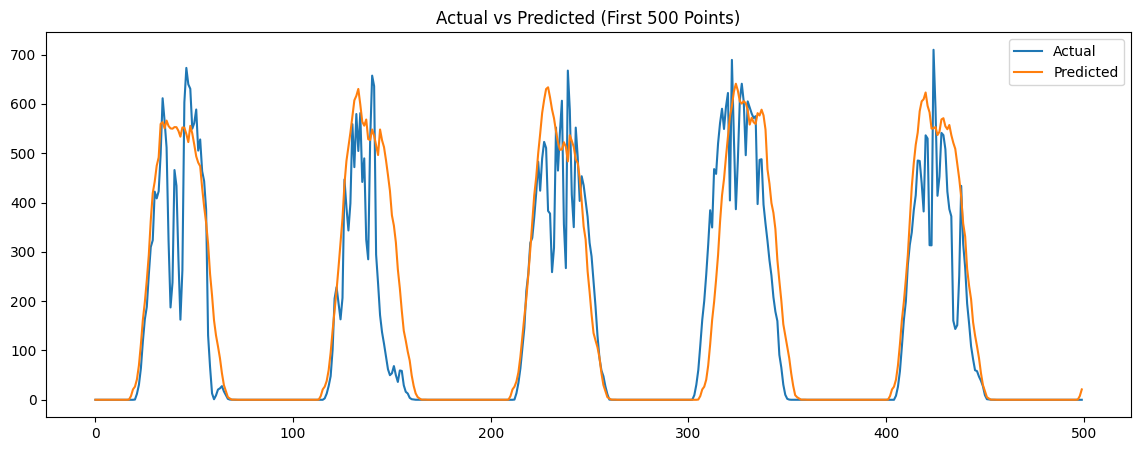

In [23]:
n = 500  # change as needed

plt.figure(figsize=(14,5))

plt.plot(y_test_np[:n], label="Actual")
plt.plot(y_test_pred_[:n], label="Predicted")

plt.title(f"Actual vs Predicted (First {n} Points)")
plt.legend()

plt.show()

In [27]:

# MAE
test_mae = mean_absolute_error(y_test_np/1000, y_test_pred_/1000)

# R2 Score
test_r2 = r2_score(y_test_np/1000, y_test_pred_/1000)

# RMSE
test_rmse = np.sqrt(mean_squared_error(y_test_np/1000, y_test_pred_/1000))

print("\nTest MAE:", test_mae)
print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)


Test MAE: 0.06146236585379728
Test R2: 0.7896743285070253
Test RMSE: 0.11254369422136423
